In [ ]:
from pathlib import Path

CFG = "/config/evaluation.yml"
CHECKPOINT = "<path_to_your_model_checkpoint.safetensors>"  # Replace with your model checkpoint path

IMAGE = "<path_to_your_geotiff_image.tif>"  # Replace with your GeoTIFF image path

PATCH_SIZE = 512
STRIDE = 256
DEVICE = "cuda"

# Output directory
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Automatically derive output names
IMAGE_NAME = Path(IMAGE).stem.replace("_ortho", "")

PRED_TIF = OUTPUT_DIR / f"{IMAGE_NAME}_pred.tif"
PRED_PNG = OUTPUT_DIR / f"{IMAGE_NAME}_pred.png"
OVERLAY_PNG = OUTPUT_DIR / f"{IMAGE_NAME}_overlay.png"
METRICS_JSON = OUTPUT_DIR / f"{IMAGE_NAME}_metrics.json"

In [ ]:
import os
import argparse
from pathlib import Path
from collections import OrderedDict

# Add project root
PROJECT_ROOT = "path/to/DTE-aerial"  # Replace with the actual path to your project root
if PROJECT_ROOT not in os.sys.path:
    os.sys.path.append(PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import rasterio
from rasterio.windows import Window

import torch

from safetensors.torch import load_file
from tqdm.auto import tqdm

from src.model import build_model
from src.utils import get_config
from src.dataset import build_loader_geotiff, GeoTIFFInferenceDataset

/home/as2114/miniconda3/envs/deadtree/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def load_model(checkpoint, device, config):

    model = build_model(config.model).to(device)

    print(f"Loading checkpoint from {checkpoint}...")
    ckpt = load_file(checkpoint, device="cpu")
    print(f"get state_dict from checkpoint...")
    state_dict = ckpt.get("state_dict", ckpt)

    state_dict = OrderedDict(
        (k.replace("module.",""),v)
        for k,v in state_dict.items()
    )
    print(f"Loading state_dict into model...")
    model.load_state_dict(state_dict)

    model = model.to(
        memory_format=torch.channels_last,
        device=device
    )

    model.eval()

    return model

In [4]:
args = argparse.Namespace(
    cfg=CFG,
    checkpoint=CHECKPOINT,
    output=str(OUTPUT_DIR)
)

config = get_config(args)

In [5]:
device = torch.device(DEVICE if torch.cuda.is_available() else "cpu")

model = load_model(
    CHECKPOINT,
    device,
    config,
)

print("Model loaded.")

2026-07-30 12:50:38,865 - root - INFO - Loading SegFormer: nvidia/segformer-b3-finetuned-ade-512-512
2026-07-30 12:50:39,021 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/nvidia/segformer-b3-finetuned-ade-512-512/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-07-30 12:50:39,031 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/nvidia/segformer-b3-finetuned-ade-512-512/a820c29fc1e53723079d94ca0e09a14d2657fae6/config.json "HTTP/1.1 200 OK"
2026-07-30 12:50:39,154 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/nvidia/segformer-b3-finetuned-ade-512-512/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-07-30 12:50:39,272 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/nvidia/segformer-b3-finetuned-ade-512-512/resolve/main/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-07-30 12:50:39,391 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/nvidia/segformer-b3-finetune

Loading checkpoint from /home/as2114/code/DTE-aerial/model/DTE-aerial-model/DTE_aerial_model.safetensors...
get state_dict from checkpoint...
Loading state_dict into model...
Model loaded.


In [6]:
def get_positions(length, patch_size, stride):
    """Generate sliding window start positions including the last patch."""
    positions = list(range(0, max(length - patch_size + 1, 1), stride))

    if len(positions) == 0:
        positions = [0]

    if positions[-1] != length - patch_size:
        positions.append(max(0, length - patch_size))

    return positions



In [7]:
dataset, loader = build_loader_geotiff(
    IMAGE,
    batch_size=4,
    tile_size=640,
    padding=70,
)

In [8]:
import numpy as np
import torch
from tqdm.auto import tqdm


@torch.inference_mode()
def run_geotiff_inference(
    model,
    loader,
    dataset,
    device,
    num_classes,
):
    """
    Run inference on a GeoTIFFInferenceDataset.

    Returns
    -------
    prediction : np.ndarray
        (H,W) uint8 semantic mask
    """

    prediction = np.zeros(
        (dataset.height, dataset.width),
        dtype=np.uint8,
    )

    crop_size = dataset.crop_size
    padding = dataset.padding

    model.eval()

    for batch in tqdm(loader, desc="Inference"):

        images = batch["image"].to(
            device=device,
            memory_format=torch.channels_last,
        )

        logits = model(images)

        pred = torch.softmax(
            logits,
            dim=1,
        ).argmax(1)

        pred = pred.cpu().numpy()

        B = pred.shape[0]

        for i in range(B):

            #############################
            # Crop centre prediction
            #############################

            tile = pred[
                i,
                padding:-padding,
                padding:-padding,
            ]

            #############################
            # Where does it go?
            #############################

            x = batch["x"][i]
            y = batch["y"][i]

            x_end = min(
                x + crop_size,
                dataset.width,
            )

            y_end = min(
                y + crop_size,
                dataset.height,
            )

            tile = tile[
                : y_end - y,
                : x_end - x,
            ]

            prediction[
                y:y_end,
                x:x_end,
            ] = tile.astype(np.uint8)

    return prediction

In [9]:
prediction = run_geotiff_inference(
    model=model,
    loader=loader,
    dataset=dataset,
    device=device,
    num_classes=config.model.num_classes,
)

dataset.close()

Inference: 100%|██████████| 490/490 [00:50<00:00,  9.75it/s]


In [10]:
profile = dataset.profile.copy()
profile.update(
    driver="GTiff",
    count=1,
    dtype=rasterio.uint8,
    compress="lzw"
)

# Remove RGB-specific options
profile.pop("photometric", None)
profile.pop("PHOTOMETRIC", None)
profile.pop("interleave", None)
profile.pop("INTERLEAVE", None)
profile.pop("jpeg_quality", None)
profile.pop("JPEG_QUALITY", None)

with rasterio.open(PRED_TIF, "w", **profile) as dst:
    dst.write(prediction, 1)

print("Saved:", PRED_TIF)

Saved: outputs/375_spain_16_09_2023_andy_8_pred.tif


(np.float64(-0.5), np.float64(19967.5), np.float64(24319.5), np.float64(-0.5))

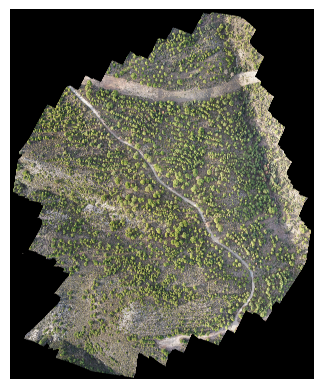

In [11]:
with rasterio.open(IMAGE) as src:
    rgb = src.read([1, 2, 3]).transpose(1, 2, 0)

plt.imshow(rgb)
plt.axis("off")

In [30]:
prediction_rgb = (rgb * 255).astype(np.uint8).copy()

# Forest -> green
prediction_rgb[prediction == 1] = [34, 139, 34]

# Dead trees -> orange
prediction_rgb[prediction == 2] = [255, 140, 0]

Text(0.5, 1.0, 'Prediction only')

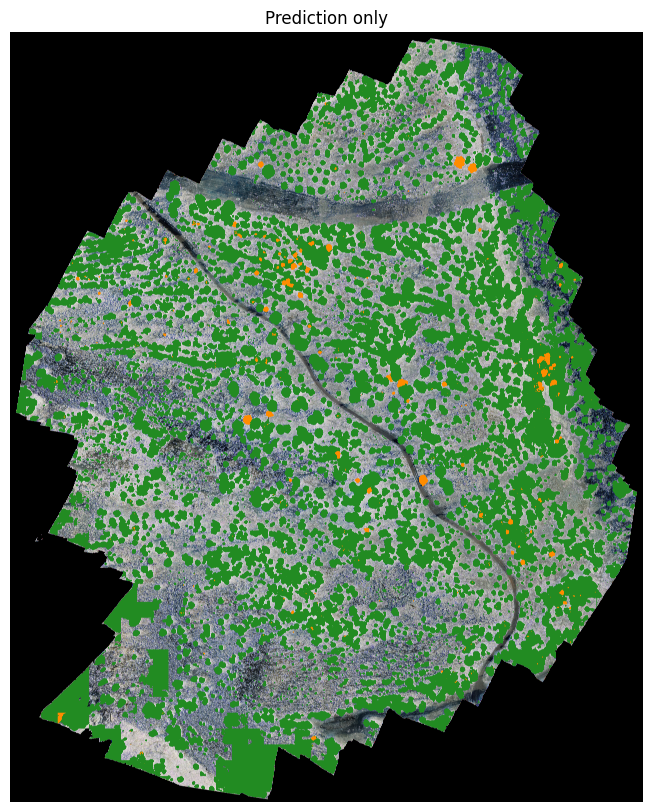

In [35]:
plt.figure(figsize=(10, 10))
plt.imshow(prediction_rgb)
plt.axis("off")
plt.title("Prediction only")

In [ ]:
plt.imsave(
    PRED_PNG,
    prediction_rgb,
)

print(f"Saved mask     : {PRED_PNG}")
print(f"Saved overlay  : {OVERLAY_PNG}")